In [3]:
from qiskit import QuantumCircuit         # Importa la clase para crear circuitos cuánticos
from qiskit_aer import AerSimulator        # Importa el simulador moderno de Qiskit
import numpy as np                         # Librería matemática para calcular ángulos

# Parámetros financieros (simple)
K = 1.0                                    # Strike de una opción
ST = 1.4                                   # Precio final simulado del activo
payoff = max(ST - K, 0)                    # Payoff de una call: max(ST - K, 0)

print("Payoff clásico:", payoff)           # Imprime el resultado clásico para comparar

# Creamos un circuito cuántico con 1 qubit
qc = QuantumCircuit(1)

# Esta puerta RY rota el qubit, generando una probabilidad de observar |1>
# El ángulo se calcula para que P(|1>) = 0.7 (esto lo usamos como ejemplo)
qc.ry(2 * np.arcsin(np.sqrt(0.7)), 0)

# Añadimos mediciones para leer el valor final del qubit
qc.measure_all()

# Instanciamos el simulador local (no gasta nube ni créditos)
sim = AerSimulator()

# Ejecutamos el circuito 800 veces para estimar probabilidades
result = sim.run(qc, shots=800).result()

# Convertimos los resultados en un diccionario: {'0': xxx, '1': yyy}
counts = result.get_counts()

counts    # Esto muestra cuántas veces sale 0 y cuántas veces sale 1


Payoff clásico: 0.3999999999999999


{'0': 258, '1': 542}

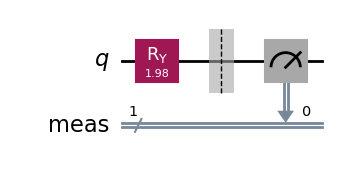

In [4]:
qc.draw('mpl')